notebook creates figures of the cooling / regional temperature annual mean timseries under HiLLA and SSP245 scenarios

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
from xmip.preprocessing import rename_cmip6
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import json
import cftime
import matplotlib
import warnings
import matplotlib.pyplot as plt
from Utils import get_ds_from_ceda
from Utils import weighted_annual_resample
import seaborn as sns
warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'font.size': 15})

from HiLLA_utils import get_ds, cut_incomplete_years, spatial_mean, set_time_to_center_of_bounds

# get standard variable names, settings for plotting, region bounds etc. 
from config import models, regions, HiLLA_altitudes, path_archive, ens_mems_arise_UK, UKESM_ARISE_run_IDs, ens_mems_CE, colours, model_colors

## read in the arise inj magnitudes, calculated from raw files in "x0_get_ARISE_injs.ipynb"
with open("../intermediate_outputs/arise_inj_mags.json", "r") as f:
    arise_injs = json.load(f)

In [2]:
## UKESM (note the combined run u-dm204dn587 is the 35 year run for 13km 60°)
ds_HiLLA_13_UK = weighted_annual_resample(cut_incomplete_years(get_ds(run = 'u-dm204dn587', var='tas', table='Amon').sel(time=slice(None, '2069'))), var='tas')
ds_HiLLA_15_UK = weighted_annual_resample(cut_incomplete_years(get_ds(run = 'u-dn760', var='tas', table='Amon').sel(time=slice(None, '2069'))), var='tas')

## repeat for CESM
ds_HiLLA_13_CE = weighted_annual_resample(set_time_to_center_of_bounds(xr.open_dataset(path_archive+'CESM_data/Temperature/case01_60NS_13km_MAMJ_6Tg_TREFHT.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069')), var='tas')
ds_HiLLA_15_CE = weighted_annual_resample(set_time_to_center_of_bounds(xr.open_dataset(path_archive+'CESM_data/Temperature/case04_60NS_15km_MAMJ_6Tg_TREFHT.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069')), var='tas')

## repeat for E3SM
ds_HiLLA_13_E3 = weighted_annual_resample(set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.01.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069')), var='tas')
ds_HiLLA_15_E3 = weighted_annual_resample(set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.04.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069')), var='tas')

## combine into a dict
HiLLA_data = {'UKESM':{'13km':ds_HiLLA_13_UK, '15km':ds_HiLLA_15_UK},
              'CESM':{'13km':ds_HiLLA_13_CE, '15km':ds_HiLLA_15_CE},
              'E3SM':{'13km':ds_HiLLA_13_E3, '15km':ds_HiLLA_15_E3}}

## reduce HiLLA data to annually resampled timeseries
timeseries_dicts_models = []
for model in models:
    timeseries_dicts = []
    for alt in HiLLA_altitudes:
        data = HiLLA_data[model][alt]
        timeseries_dicts.append(dict(zip(regions, [spatial_mean(data, region) for region in regions])))
    
    timeseries_dicts_models.append(dict(zip(HiLLA_altitudes, timeseries_dicts)))

HiLLA_timeseries_dict = dict(zip(models, timeseries_dicts_models))

In [3]:
DS_ssp245_tas_UK = weighted_annual_resample(get_ds_from_ceda(model='UKESM1-0-LL', centre='MOHC', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='tas', members=ens_mems_arise_UK, 
                              table='Amon', grid='gn'), var='tas').sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'})

DS_ssp245_tas_CE = weighted_annual_resample(get_ds_from_ceda(model='CESM2-WACCM', centre='NCAR', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='tas', members=ens_mems_CE, 
                              table='Amon', grid='gn'), var='tas').sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'})

ds_ssp245_tas_E3 =  set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.control.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'})
ds_ssp245_tas_E3 = weighted_annual_resample(cut_incomplete_years(ds_ssp245_tas_E3), var='tas').sel(time=slice('2015', '2069'))
DS_ssp245_tas_E3 = xr.concat([ds_ssp245_tas_E3], dim='Ensemble_member')
#ds_ssp245_tas_E3['Ensemble_member'] = 'r1'

SSP245_data = {'UKESM':DS_ssp245_tas_UK, 'CESM':DS_ssp245_tas_CE, 'E3SM':DS_ssp245_tas_E3}

## reduce SSP2-4.5 data to annually resampled timeseries
timeseries_dicts = []
for model in models:
    print(model)
    data = SSP245_data[model].load()
    timeseries_dicts.append(dict(zip(regions, [spatial_mean(data, region) for region in regions])))
    
SSP245_timeseries_dict = dict(zip(models, timeseries_dicts))

UKESM
CESM
E3SM


In [4]:
### save cooling maps to intermediate outputs for re-use elsewhere:
for model in models:
    for alt in ['13km', '15km']:
        cooling = HiLLA_data[model][alt] - SSP245_data[model].mean('Ensemble_member')
        cooling.to_netcdf('../intermediate_outputs/cooling_annual/{m}_HiLLA-{a}_cooling.nc'.format(m=model, a=alt))

In [5]:
matplotlib.rcParams.update({'font.size': 15})

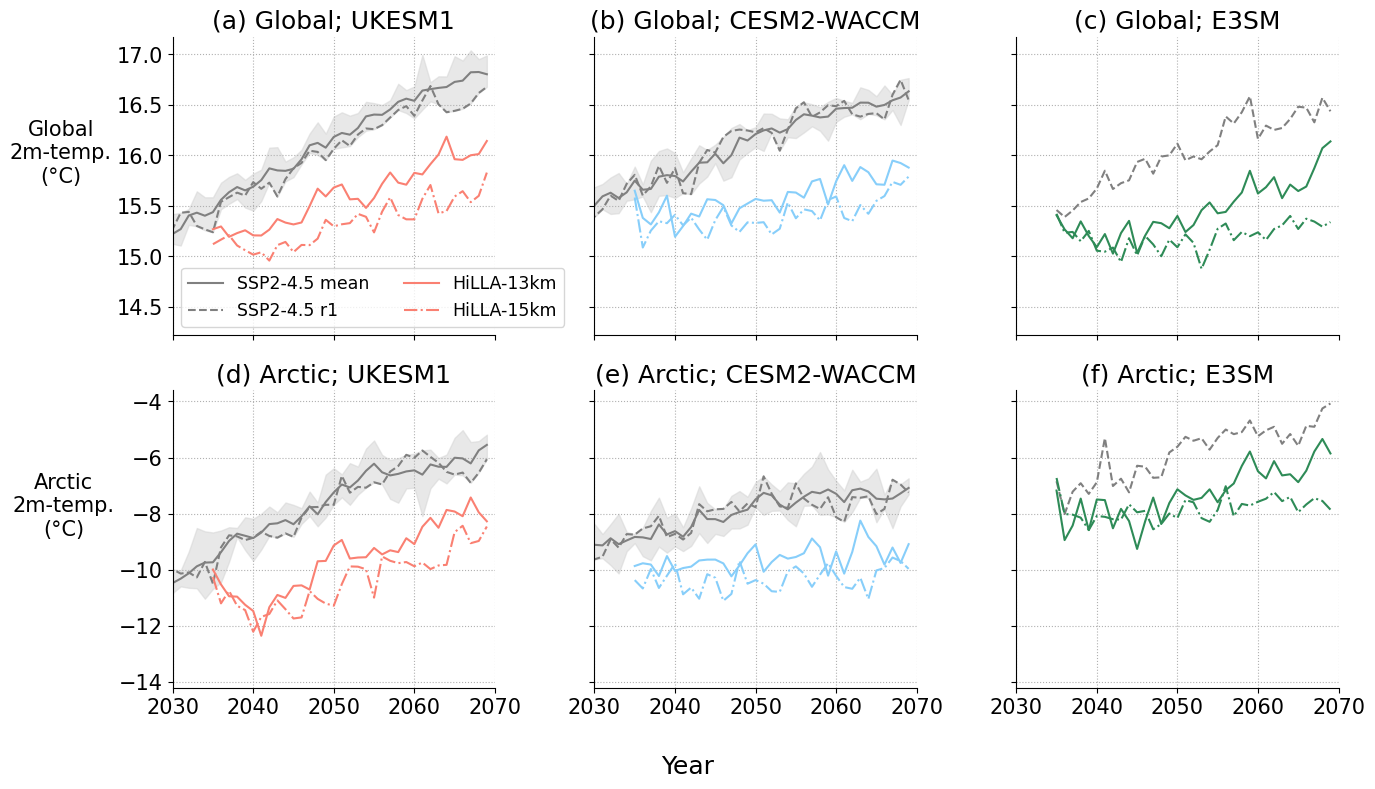

In [6]:
fig, axs = plt.subplots(2, 3, figsize=(14, 8), sharey='row', sharex='col')
t_col = 'black'
alt_linestyles = {'13km':'solid', '15km':'-.'}
kelvinconv = 273.15

piCo_global_dict = {'UKESM':kelvinconv, 'CESM':kelvinconv, 'E3SM':kelvinconv} # fill in with PI values to shift from abs temps to warming
piCo_arctic_dict = {'UKESM':kelvinconv, 'CESM':kelvinconv, 'E3SM':kelvinconv} # fill in with PI values to shift from abs temps to warming


j=0
for model in models:
    i=0
    for region in ['Global', 'Arctic']:
        ax = axs[i, j]
        
        ts_ssp245 = SSP245_timeseries_dict[model][region].tas
        piCo_global = piCo_global_dict[model]
        
        if model in ['UKESM', 'CESM']:
            ax.plot(ts_ssp245.mean('Ensemble_member').time.dt.year.values, (ts_ssp245.mean('Ensemble_member') - piCo_global), c=colours['ssp245'], label='SSP2-4.5 mean')
            ax.fill_between(ts_ssp245.isel(Ensemble_member=0).time.dt.year.values, 
                            ts_ssp245.min('Ensemble_member').values - piCo_global, 
                            ts_ssp245.max('Ensemble_member').values - piCo_global, 
                            color=colours['ssp245_light'], alpha=0.5)
        ax.plot(ts_ssp245.isel(Ensemble_member=0).time.dt.year.values, (ts_ssp245.isel(Ensemble_member=0) - piCo_global), c=colours['ssp245'], ls='--', label='SSP2-4.5 r1')
        for alt in HiLLA_altitudes:
            HiLLA = HiLLA_timeseries_dict[model][alt][region]
            ax.plot(HiLLA.time.dt.year,(HiLLA.tas - piCo_global),
            c=model_colors[model], ls= alt_linestyles[alt], label='HiLLA-{}'.format(alt))
            
        ax.grid(ls='dotted')
        if region == 'Global':
            if model == 'UKESM':
                ax.legend(fontsize='small', ncols=2)
        i=i+1
    j=j+1

for ax in axs.flatten():
    ax.set_xlim(2030, 2070)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('')
    ax.set_xlabel('')

axs[0, 0].set_title('(a) Global; UKESM1')
axs[0, 1].set_title('(b) Global; CESM2-WACCM')
axs[0, 2].set_title('(c) Global; E3SM')
axs[1, 0].set_title('(d) Arctic; UKESM1')
axs[1, 1].set_title('(e) Arctic; CESM2-WACCM')
axs[1, 2].set_title('(f) Arctic; E3SM')


axs[0, 0].set_ylabel('Global\n2m-temp.\n(°C)', rotation=0, labelpad=40)
axs[1, 0].set_ylabel('Arctic\n2m-temp.\n(°C)', rotation=0, labelpad=40)

fig.supxlabel('Year')

plt.tight_layout()
plt.savefig('Figures/tas_summary.jpg', dpi=300)

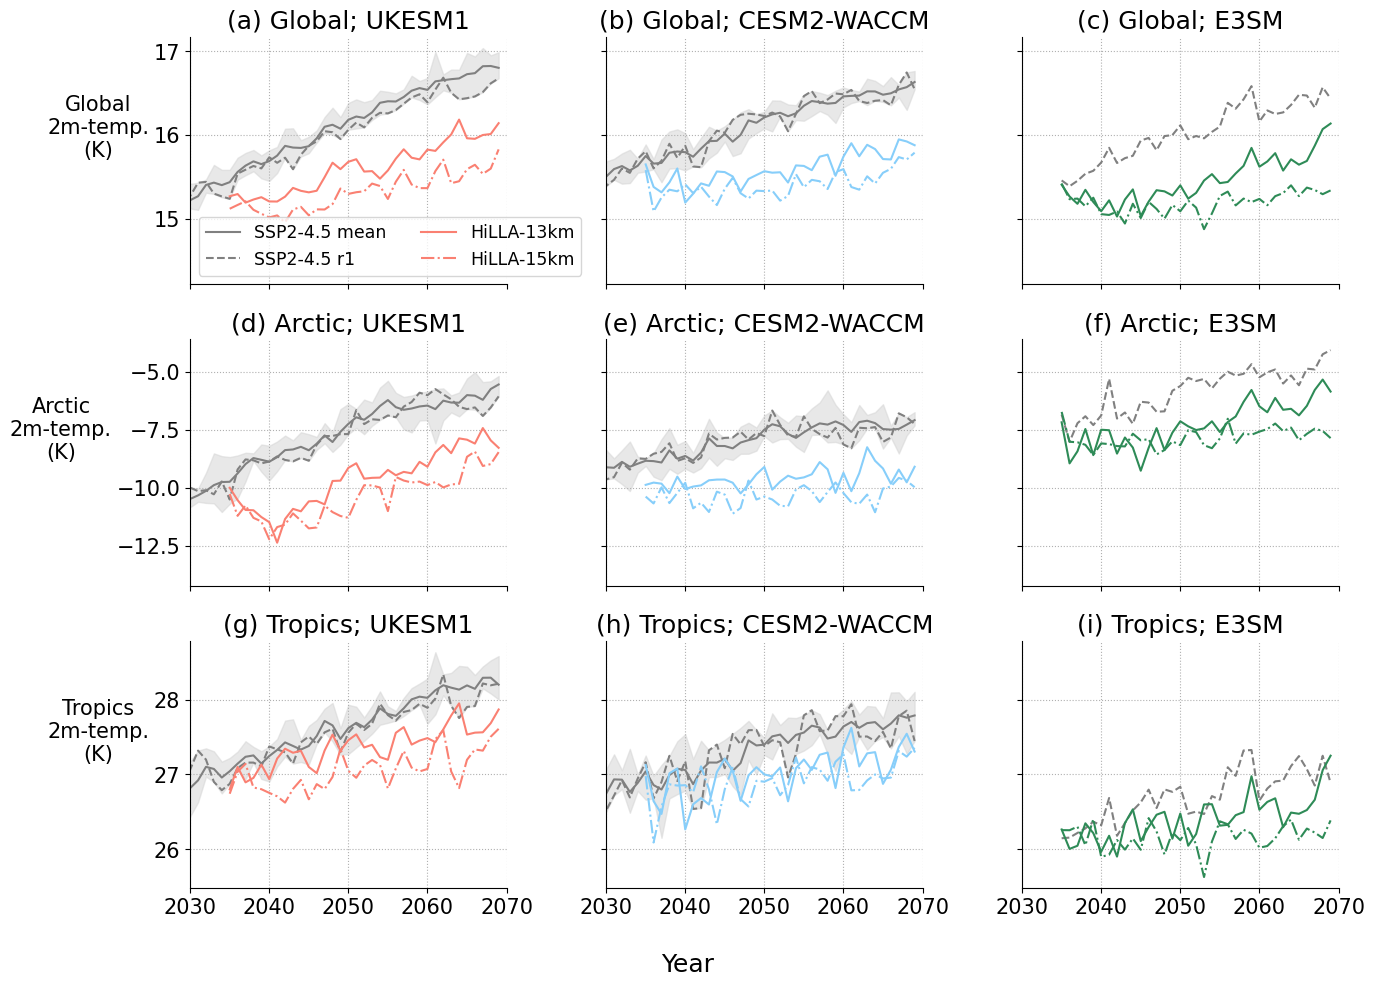

In [7]:
fig, axs = plt.subplots(3, 3, figsize=(14, 10), sharey='row', sharex='col')
t_col = 'black'
alt_linestyles = {'13km':'solid', '15km':'-.'}

piCo_global_dict = {'UKESM':kelvinconv, 'CESM':kelvinconv, 'E3SM':kelvinconv} # fill in with PI values to shift from abs temps to warming
piCo_arctic_dict = {'UKESM':kelvinconv, 'CESM':kelvinconv, 'E3SM':kelvinconv} # fill in with PI values to shift from abs temps to warming


j=0
for model in models:
    i=0
    for region in ['Global', 'Arctic', 'Tropics']:
        ax = axs[i, j]
        
        ts_ssp245 = SSP245_timeseries_dict[model][region].tas
        piCo_global = piCo_global_dict[model]
        
        if model in ['UKESM', 'CESM']:
            ax.plot(ts_ssp245.mean('Ensemble_member').time.dt.year.values, (ts_ssp245.mean('Ensemble_member') - piCo_global), c=colours['ssp245'], label='SSP2-4.5 mean')
            ax.fill_between(ts_ssp245.isel(Ensemble_member=0).time.dt.year.values, 
                            ts_ssp245.min('Ensemble_member').values - piCo_global, 
                            ts_ssp245.max('Ensemble_member').values - piCo_global, 
                            color=colours['ssp245_light'], alpha=0.5)
        ax.plot(ts_ssp245.isel(Ensemble_member=0).time.dt.year.values, (ts_ssp245.isel(Ensemble_member=0) - piCo_global), c=colours['ssp245'], ls='--', label='SSP2-4.5 r1')
        for alt in HiLLA_altitudes:
            HiLLA = HiLLA_timeseries_dict[model][alt][region]
            ax.plot(HiLLA.time.dt.year,(HiLLA.tas - piCo_global),
            c=model_colors[model], ls= alt_linestyles[alt], label='HiLLA-{}'.format(alt))
            
        ax.grid(ls='dotted')
        if region == 'Global':
            if model == 'UKESM':
                ax.legend(fontsize='small', ncols=2)
        i=i+1
    j=j+1

for ax in axs.flatten():
    ax.set_xlim(2030, 2070)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('')
    ax.set_xlabel('')

axs[0, 0].set_title('(a) Global; UKESM1')
axs[0, 1].set_title('(b) Global; CESM2-WACCM')
axs[0, 2].set_title('(c) Global; E3SM')
axs[1, 0].set_title('(d) Arctic; UKESM1')
axs[1, 1].set_title('(e) Arctic; CESM2-WACCM')
axs[1, 2].set_title('(f) Arctic; E3SM')
axs[2, 0].set_title('(g) Tropics; UKESM1')
axs[2, 1].set_title('(h) Tropics; CESM2-WACCM')
axs[2, 2].set_title('(i) Tropics; E3SM')


axs[0, 0].set_ylabel('Global\n2m-temp.\n(K)', rotation=0, labelpad=40)
axs[1, 0].set_ylabel('Arctic\n2m-temp.\n(K)', rotation=0, labelpad=40)
axs[2, 0].set_ylabel('Tropics\n2m-temp.\n(K)', rotation=0, labelpad=40)

fig.supxlabel('Year')

plt.tight_layout()
plt.savefig('Figures/tas_summary_with_tropics.jpg', dpi=300)

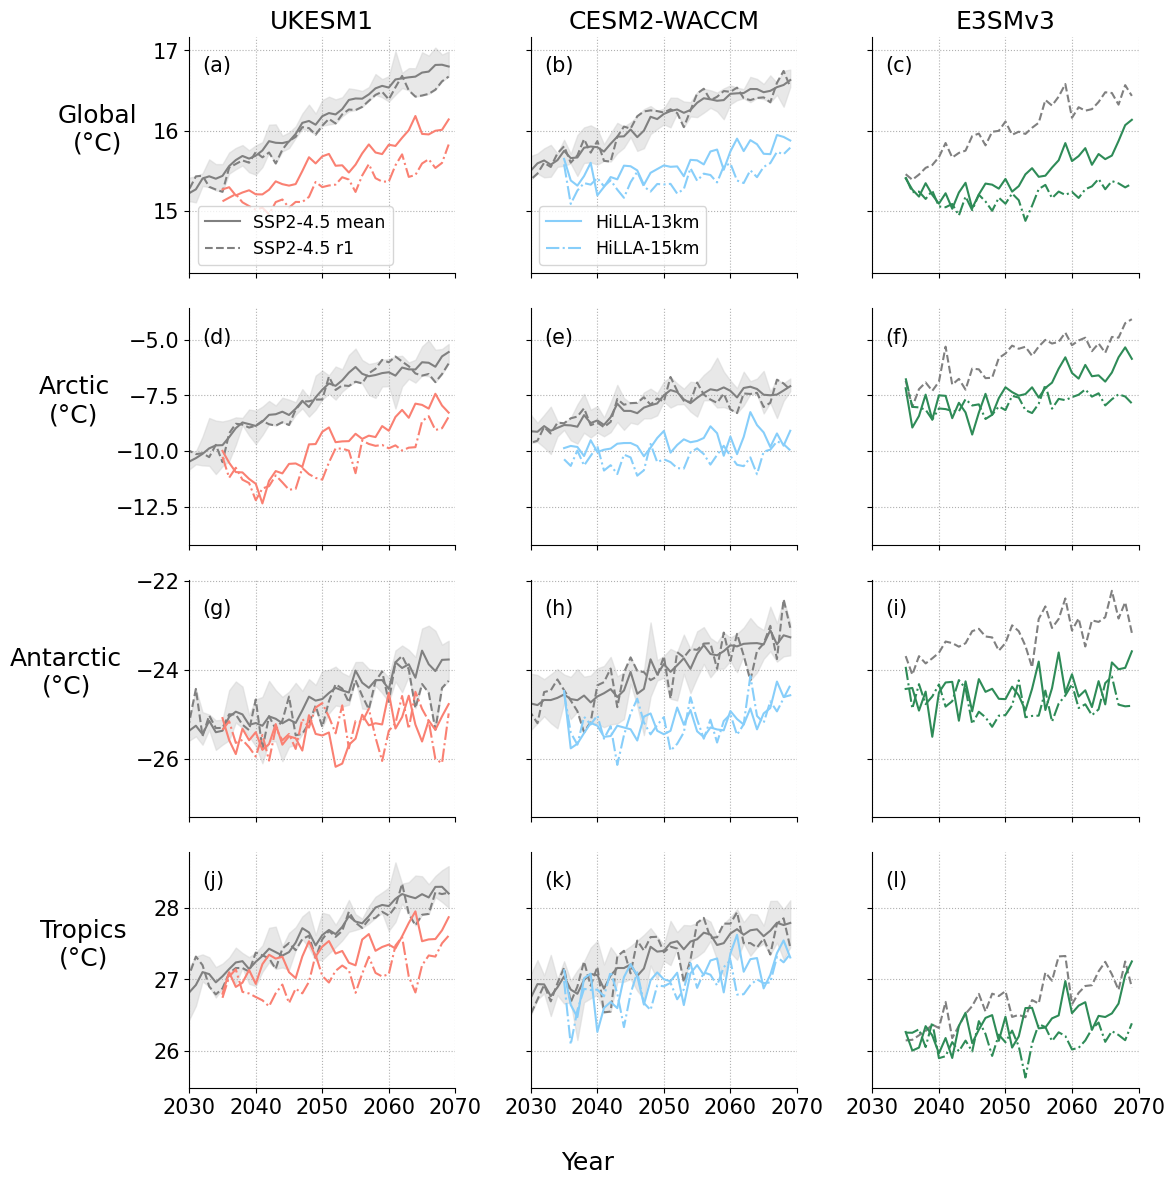

In [8]:
fig, axs = plt.subplots(4, 3, figsize=(12, 12), sharey='row', sharex='col')
t_col = 'black'
alt_linestyles = {'13km':'solid', '15km':'-.'}

piCo_global_dict = {'UKESM':kelvinconv, 'CESM':kelvinconv, 'E3SM':kelvinconv} # fill in with PI values to shift from abs temps to warming
piCo_arctic_dict = {'UKESM':kelvinconv, 'CESM':kelvinconv, 'E3SM':kelvinconv} # fill in with PI values to shift from abs temps to warming


j=0
for model in models:
    i=0
    for region in ['Global', 'Arctic', 'Antarctic', 'Tropics']:
        ax = axs[i, j]
        
        ts_ssp245 = SSP245_timeseries_dict[model][region].tas
        piCo_global = piCo_global_dict[model]
        
        if model in ['UKESM', 'CESM']:
            ax.plot(ts_ssp245.mean('Ensemble_member').time.dt.year.values, (ts_ssp245.mean('Ensemble_member') - piCo_global), c=colours['ssp245'])#, label='SSP2-4.5 mean')
            ax.fill_between(ts_ssp245.isel(Ensemble_member=0).time.dt.year.values, 
                            ts_ssp245.min('Ensemble_member').values - piCo_global, 
                            ts_ssp245.max('Ensemble_member').values - piCo_global, 
                            color=colours['ssp245_light'], alpha=0.5)
        ax.plot(ts_ssp245.isel(Ensemble_member=0).time.dt.year.values, (ts_ssp245.isel(Ensemble_member=0) - piCo_global), c=colours['ssp245'], ls='--')#, label='SSP2-4.5 r1')
        for alt in HiLLA_altitudes:
            HiLLA = HiLLA_timeseries_dict[model][alt][region]
            ax.plot(HiLLA.time.dt.year,(HiLLA.tas - piCo_global),
            c=model_colors[model], ls= alt_linestyles[alt])#, label='HiLLA-{}'.format(alt))
            
        ax.grid(ls='dotted')
        if region == 'Global':
            if model == 'UKESM':
                ax.plot([], [], c=colours['ssp245'], label='SSP2-4.5 mean')
                ax.plot([], [], c=colours['ssp245'], ls='--', label='SSP2-4.5 r1')
                ax.legend(fontsize='small')
            elif model == 'CESM':
                for alt in HiLLA_altitudes:
                    ax.plot([], [], c=model_colors[model], ls=alt_linestyles[alt], label='HiLLA-{}'.format(alt))
                ax.legend(fontsize='small')
        i=i+1
    j=j+1

m=0
labs = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)', '(i)', '(j)', '(k)', '(l)']
for ax in axs.flatten():
    ax.set_xlim(2030, 2070)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.text(0.05, 0.92, labs[m], transform=ax.transAxes, fontsize='medium', va='top', ha='left')
    m=m+1

axs[0, 0].set_title('UKESM1', fontsize='large')
axs[0, 1].set_title('CESM2-WACCM', fontsize='large')
axs[0, 2].set_title('E3SMv3', fontsize='large')
#axs[1, 0].set_title('(d) Arctic; UKESM1')
#axs[1, 1].set_title('(e) Arctic; CESM2-WACCM')
#axs[1, 2].set_title('(f) Arctic; E3SM')
#axs[2, 0].set_title('(g) Tropics; UKESM1')
#axs[2, 1].set_title('(h) Tropics; CESM2-WACCM')
#axs[2, 2].set_title('(i) Tropics; E3SM')


axs[0, 0].set_ylabel('Global\n(°C)', rotation=0, labelpad=40, fontsize='large')
axs[1, 0].set_ylabel('Arctic\n(°C)', rotation=0, labelpad=30, fontsize='large')
axs[2, 0].set_ylabel('Antarctic\n(°C)', rotation=0, labelpad=50, fontsize='large')
axs[3, 0].set_ylabel('Tropics\n(°C)', rotation=0, labelpad=50, fontsize='large')

fig.supxlabel('Year')

plt.tight_layout()
plt.savefig('Figures/tas_summary_all.jpg', dpi=300)

In [9]:
import scipy

# print the AA ratio for the three models:
for model in models:
    ts_ssp245_global = SSP245_timeseries_dict[model]['Global'].mean('Ensemble_member').tas
    lr_global = scipy.stats.linregress(ts_ssp245_global.time.dt.year.values, ts_ssp245_global.values).slope

    ts_ssp245_arctic = SSP245_timeseries_dict[model]['Arctic'].mean('Ensemble_member').tas
    lr_arctic = scipy.stats.linregress(ts_ssp245_arctic.time.dt.year.values, ts_ssp245_arctic.values).slope

    print(model, lr_global, lr_arctic, lr_arctic/lr_global)

UKESM 0.04495670889132542 0.1418553299349646 3.1553762148798254
CESM 0.02973324308912759 0.05209927348332151 1.752223036254407
E3SM 0.03139595131178469 0.08373090412796369 2.666933175442106


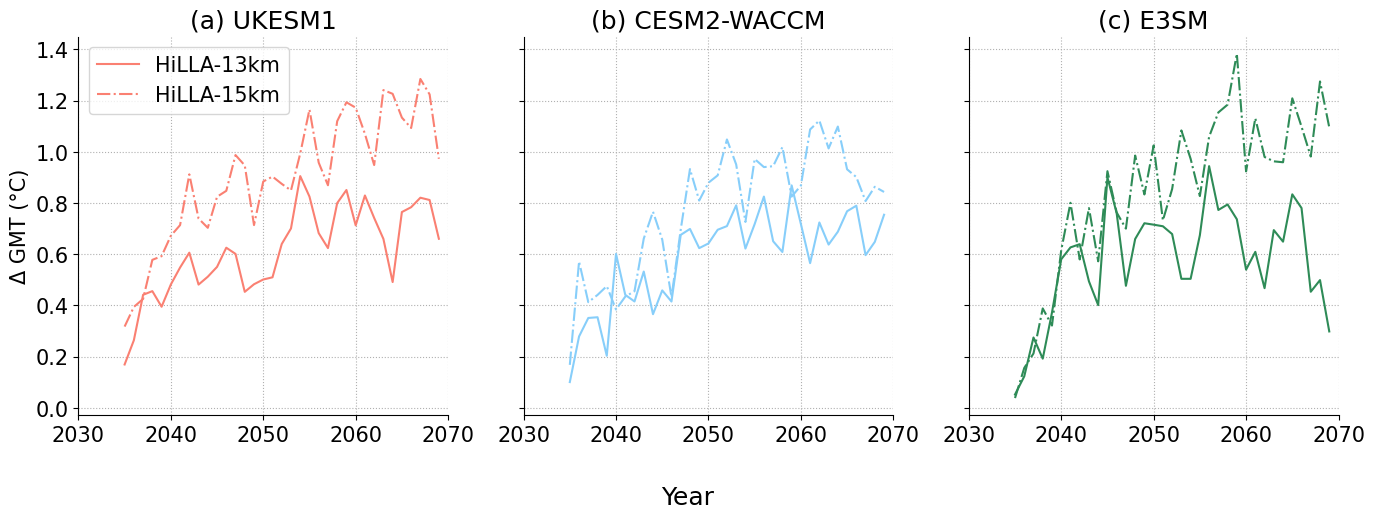

In [10]:
### show cooling mag evolutions: 


region = 'Global'

HiLLA_cooling_ts = SSP245_timeseries_dict[model][region].tas - HiLLA_timeseries_dict[model][alt][region].tas


fig, axs = plt.subplots(1, 3, figsize=(14, 5), sharey='row', sharex='col')
t_col = 'black'
alt_linestyles = {'13km':'solid', '15km':'-.'}

i=0
for model in models:
    ax = axs[i]

    for alt in ['13km', '15km']:
        HiLLA_cooling_ts = (SSP245_timeseries_dict[model][region].tas - HiLLA_timeseries_dict[model][alt][region].tas).mean('Ensemble_member')
        ax.plot(HiLLA_cooling_ts.time.dt.year,HiLLA_cooling_ts,
                c=model_colors[model], ls= alt_linestyles[alt], label='HiLLA-{}'.format(alt))
            
        ax.grid(ls='dotted')
    i=i+1

    ax.set_xlim(2030, 2070)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('')
    ax.set_xlabel('')

axs[0].legend()
fig.supxlabel('Year')
axs[0].set_ylabel('\u0394 GMT (°C)')
plt.tight_layout()

axs[0].set_title('(a) UKESM1')
axs[1].set_title('(b) CESM2-WACCM')
axs[2].set_title('(c) E3SM')

plt.savefig('Figures/cooling_evolution_summary.jpg', dpi=300, bbox_inches='tight')

## now also plot the regional mean time mean cooling efficiencies

In [11]:
### need to also get ARISE temps

ds_list_tas = []
for path in glob.glob('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/*/Amon/tas/gn/*/'):
    ds_list_tas.append(rename_cmip6(xr.open_mfdataset(path+'*.nc')))

DS_ARISE_tas_UK = weighted_annual_resample(xr.concat(ds_list_tas, dim='Ensemble_member').sel(time=slice('2015', '2069')), 'tas').rename({'x':'longitude', 'y':'latitude'})


## repeat for CESM
ds_list_tas = []
path = '/gws/ssde/j25b/cpom/aduffey/ARISE/CESM/arise/TREFHT/'
files = os.listdir(path)
files = [x for x in files if ".nc" in x]

# we keep only first 5 members to align with the ssp245 runs available, this also means there are 5 members for both models
files = [x for x in files if int(x.split('.')[5]) < 6] 
for file in files:
    ds = rename_cmip6(xr.open_mfdataset(path+file))
    ds['Ensemble_member'] = file.split('.')[5]
    ds_list_tas.append(ds)
DS_ARISE_tas_CE = weighted_annual_resample(xr.concat(ds_list_tas, dim='Ensemble_member').sel(time=slice('2015', '2069')),'TREFHT')['TREFHT'].to_dataset(name='tas')
DS_ARISE_tas_CE = DS_ARISE_tas_CE.rename({'x':'longitude', 'y':'latitude'})


ARISE_data = {'UKESM':DS_ARISE_tas_UK,
              'CESM':DS_ARISE_tas_CE}


## save the ARISE cooling for use elsewhere:
ARISE_cooling_CESM = ARISE_data['CESM'].mean('Ensemble_member') - SSP245_data['CESM'].mean('Ensemble_member')
ARISE_cooling_CESM.to_netcdf('../intermediate_outputs/cooling_annual/CESM_ARISE_cooling.nc')

ARISE_cooling_UKESM = ARISE_data['UKESM'].mean('Ensemble_member') - SSP245_data['UKESM'].mean('Ensemble_member')
ARISE_cooling_UKESM.to_netcdf('../intermediate_outputs/cooling_annual/UKESM_ARISE_cooling.nc')

ARISE_cooling_dict = {'UKESM':ARISE_cooling_UKESM, 'CESM':ARISE_cooling_CESM}

## also get the regional timeseries
timeseries_dicts = []
for model in ['UKESM', 'CESM']:
    data = ARISE_data[model]
    timeseries_dicts.append(dict(zip(regions, [spatial_mean(data, region) for region in regions])))

ARISE_timeseries_dict = dict(zip(['UKESM', 'CESM'], timeseries_dicts))

In [12]:
def abs_temp(timeseries_ds, t1='2050', t2='2069'):
    return timeseries_ds.sel(time=slice(t1, t2)).mean(['time']).tas.values.item()


## reduce HiLLA temp data to single values for abs temp. over time period:
dicts_models = []
for model in models:
    for alt in HiLLA_altitudes:
        dicts_models.append(dict(zip(HiLLA_altitudes, [abs_temp(HiLLA_timeseries_dict[model][alt]['Global']) for alt in HiLLA_altitudes])))
HiLLA_abs_temps_dict = dict(zip(models, dicts_models))


### also get ARISE abs temps

ARISE_abs_temp_dict = {'UKESM':abs_temp(ARISE_timeseries_dict['UKESM']['Global'].mean('Ensemble_member')),
                       'CESM':abs_temp(ARISE_timeseries_dict['CESM']['Global'].mean('Ensemble_member'))}


UKESM Global
[1.5171331670507209, 1.3135438231628578, 1.5459447669218893, 1.4572384724285097, 1.425208304107132]
0.5755207136804188 0.9188111871959563
0.5964867386270366
0.39641498837686423
0.6328712719366546
CESM Global
[1.2940384023490357, 1.2798884316738448, 1.4236234419605613, 1.4588742606224416, 1.1832302545037847]
0.69654348795342 0.9330493365668531
0.33954211431698705
0.5245329086130158
0.7026339214323182
E3SM Global
0.6427330637695832 1.0445890085094334
0.6252299241974483
nan
nan
UKESM Tropics
[1.3726989812399308, 1.1682860624688012, 1.426928110078631, 1.2904731982429738, 1.3194168643137751]
0.36412980758666436 0.7119602026562575
0.9552373571801261
0.27678679006533485
0.5411838719097157
CESM Tropics
[1.113401666807757, 1.116932542174113, 1.2949194455485435, 1.3391485420469516, 1.0415085000920858]
0.40130680276166686 0.5453074086765923
0.3588292172571178
0.33975014470501363
0.4616624231925062
E3SM Tropics
0.3501511084051572 0.725636121692105
1.0723513485282958
nan
nan
UKESM Arct

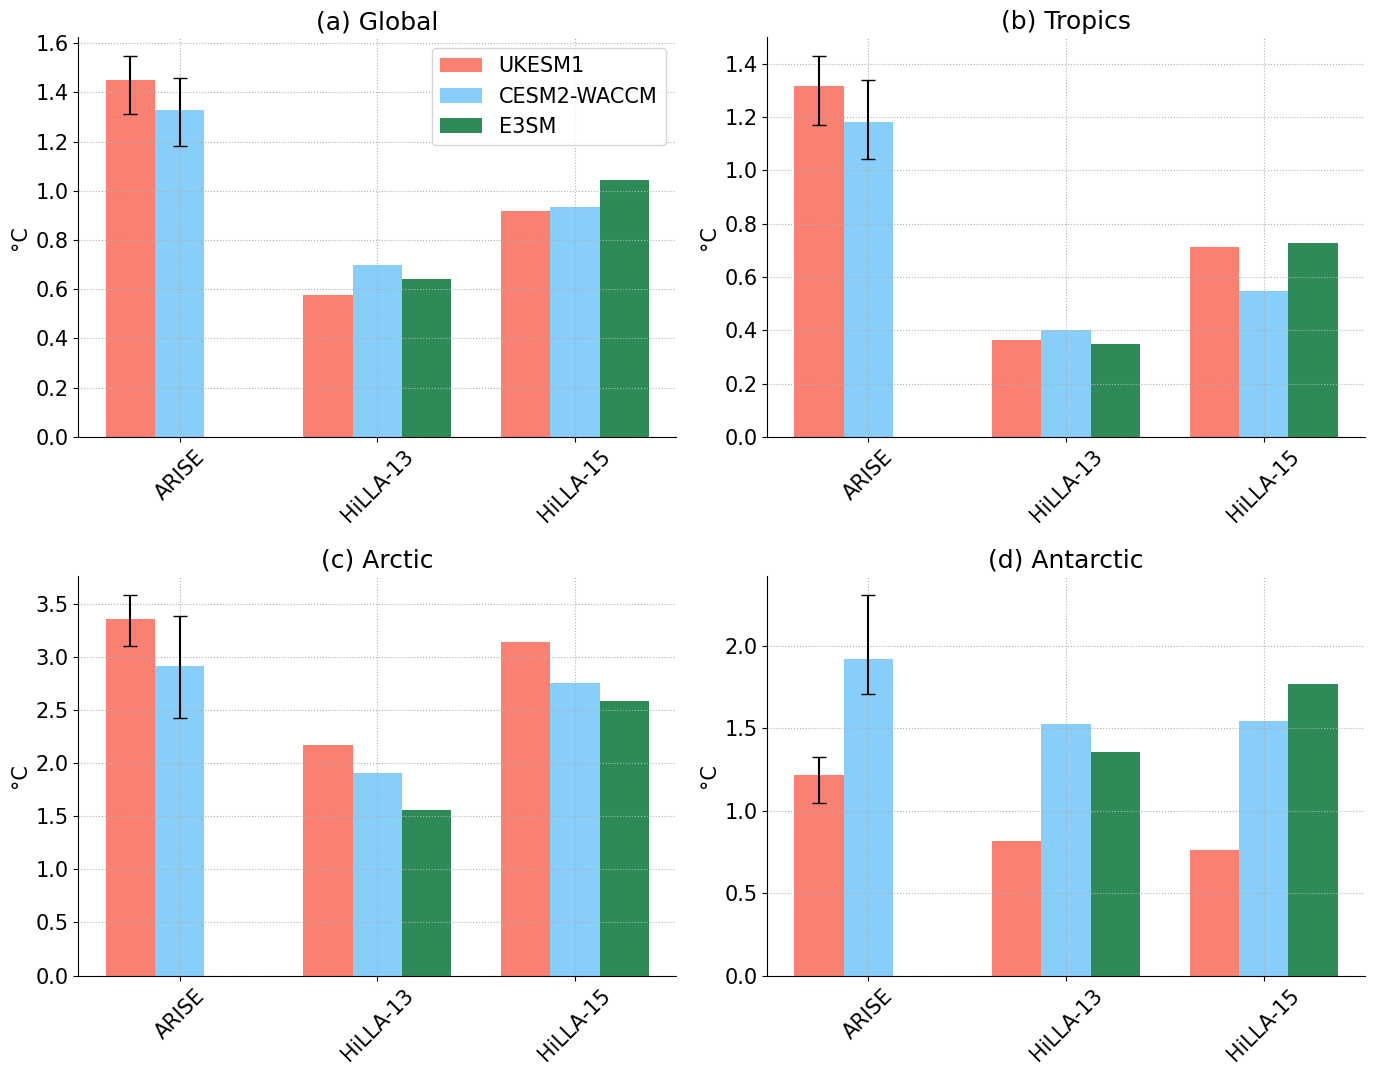

In [13]:
### plot regional coolings, v3 (combine all 4 sublots into one):


fig, axs = plt.subplots(2, 2, figsize=(14, 11))

run_labels = ['ARISE', 'HiLLA-13', 'HiLLA-15']
titles = ['(a) Global', '(b) Tropics', '(c) Arctic', '(d) Antarctic']
modeldict = {'UKESM':'UKESM1', 'CESM':'CESM2-WACCM', 'E3SM':'E3SM'}

x = np.arange(len(run_labels))  # bar positions
bar_width = 0.25  # width of each bar
offsets = [-bar_width, 0, bar_width]

l=0
for region in ['Global', 'Tropics', 'Arctic', 'Antarctic']:
    ax = axs.flatten()[l]
    i=0
    for model in models:
        print(model, region)
        if model != 'E3SM':
            
            ssp245_data = SSP245_timeseries_dict[model][region]
            mems = UKESM_ARISE_run_IDs
            arise_efficiencies = [-12*abs_temp((ARISE_timeseries_dict[model][region].isel(Ensemble_member=e) - ssp245_data.mean('Ensemble_member')))/list(arise_injs[model].values())[e] for e in range(5)]
            print(arise_efficiencies)
            arise_efficiency = np.mean(arise_efficiencies)
        if model == 'E3SM':
            arise_efficiency, arise_efficiencies = np.nan, [np.nan]
        HiLLA_13_cooling = abs_temp(HiLLA_timeseries_dict[model]['13km'][region]) - abs_temp(SSP245_timeseries_dict[model][region].isel(Ensemble_member=0))
        HiLLA_15_cooling = abs_temp(HiLLA_timeseries_dict[model]['15km'][region]) - abs_temp(SSP245_timeseries_dict[model][region].isel(Ensemble_member=0))
        HiLLA_13_efficiency, HiLLA_15_efficiency =  -HiLLA_13_cooling, -HiLLA_15_cooling

        print(HiLLA_13_efficiency, HiLLA_15_efficiency)
        print((HiLLA_15_efficiency - HiLLA_13_efficiency)/HiLLA_13_efficiency)
        print(HiLLA_13_efficiency/arise_efficiency)
        print(HiLLA_15_efficiency/arise_efficiency)
        
        #print(arise_efficiency, HiLLA_13_efficiency, HiLLA_15_efficiency)
        ax.bar(x + offsets[i], 
               [arise_efficiency, HiLLA_13_efficiency, HiLLA_15_efficiency],
               width=bar_width, label=modeldict[model], color=model_colors[model],
               yerr=[[np.abs(np.min(arise_efficiencies) - arise_efficiency), np.nan, np.nan], 
                    [np.abs(np.max(arise_efficiencies) - arise_efficiency), np.nan, np.nan]],
                error_kw={'capsize':5})
        i=i+1
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(ls='dotted')
    ax.set_title(titles[l])
    ax.set_ylabel('°C')
    ax.set_xticks(x)
    ax.set_xticklabels(run_labels, rotation=45)
    #if l < 2:
    #    ax.set_ylim(None, 1.58)
    
    if l==0:
        ax.legend(fontsize='medium')
    l=l+1


plt.tight_layout()
plt.savefig('Figures/Regional_coolings_all.jpg', dpi=300, bbox_inches='tight')


In [14]:
import numpy as np

In [15]:
0.36412980758666436/np.mean([1.3726989812399308, 1.1682860624688012, 1.426928110078631, 1.2904731982429738, 1.3194168643137751])

0.27678679006533485

In [16]:
0.40130680276166686/np.mean([1.113401666807757, 1.116932542174113, 1.2949194455485435, 1.3391485420469516, 1.0415085000920858])

0.33975014470501363

In [17]:
HiLLA_timeseries_dict[model]['13km'][region]

<xarray.Dataset> Size: 560B
Dimensions:  (time: 35)
Coordinates:
  * time     (time) object 280B 2035-01-01 00:00:00 ... 2069-01-01 00:00:00
Data variables:
    tas      (time) float64 280B 248.7 248.7 248.2 248.7 ... 249.2 249.2 249.6

UKESM Tropics 0.8437007631204355 0.905737675971221 0.6326962677990808 0.7748710644556144
UKESM Tropics vs SSP245..  1.0735295208473457 0.7499060039474749 0.9184193002146237
UKESM Tropics vs ARISE..  0.6985425080398049 0.8555137817632699
CESM Tropics 0.9466623103146777 0.8879897672611899 0.5761403411304356 0.5844357712991322
CESM Tropics vs SSP245..  0.9380216763525902 0.6086017525498846 0.6173645712216653
CESM Tropics vs ARISE..  0.6488141669778632 0.658155975267256
E3SM Tropics 0.8578304599996351 nan 0.5447846518919474 0.694661839039973
E3SM Tropics vs SSP245..  nan 0.6350726364883093 0.80978919662082
E3SM Tropics vs ARISE..  nan nan
UKESM Arctic 3.189864619278083 2.315176725668392 3.7768854249042287 3.418369102322154
CESM Arctic 1.8224815597304154 2.1922657692639316 2.7387093441922743 2.9501950314102827
E3SM Arctic 2.6756009253133035 nan 2.4276334411580898 2.4774842475409997
UKESM Antarctic 0.9156623753315288 0.8348805971629621 1.4152504345013335 0.828600329991357
CESM Antarctic 1.51

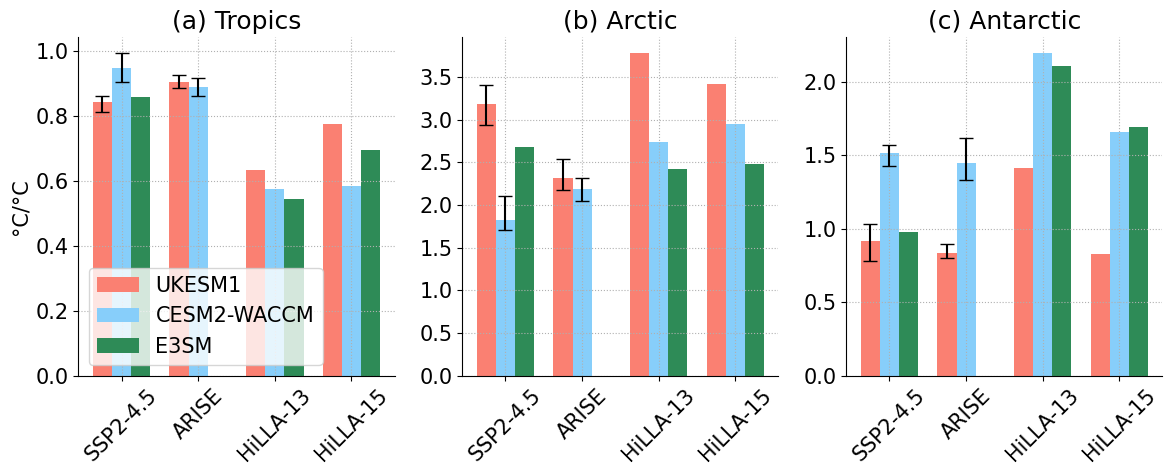

In [18]:
## delta T per unit global delta T:


### plot regional coolings, v3 (combine all 4 sublots into one):


fig, axs = plt.subplots(1, 3, figsize=(12, 5))

run_labels = ['SSP2-4.5', 'ARISE', 'HiLLA-13', 'HiLLA-15']
titles = ['(a) Tropics', '(b) Arctic', '(c) Antarctic']
modeldict = {'UKESM':'UKESM1', 'CESM':'CESM2-WACCM', 'E3SM':'E3SM'}

x = np.arange(len(run_labels))  # bar positions
bar_width = 0.25  # width of each bar
offsets = [-bar_width, 0, bar_width]

l=0
for region in ['Tropics', 'Arctic', 'Antarctic']:
    ax = axs[l]
    i=0
    for model in models:
        #print(model, region)
        if model != 'E3SM':
            
            arise_global_coolings = [abs_temp((ARISE_timeseries_dict[model]['Global'].isel(Ensemble_member=e) - SSP245_timeseries_dict[model]['Global'].mean('Ensemble_member'))) for e in range(5)]
            arise_coolings = [abs_temp((ARISE_timeseries_dict[model][region].isel(Ensemble_member=e) - SSP245_timeseries_dict[model][region].mean('Ensemble_member'))) for e in range(5)]
            arise_ratios = [arise_coolings[e]/arise_global_coolings[e] for e in range(5)]
            arise_ratio = np.mean(arise_coolings)/np.mean(arise_global_coolings)
            
            global_warmings = [abs_temp(SSP245_timeseries_dict[model]['Global'].isel(Ensemble_member=e), t1='2050', t2='2069') - abs_temp(SSP245_timeseries_dict[model]['Global'].mean('Ensemble_member'), t1='2015', t2='2035') for e in range(5)]
            regional_warmings = [abs_temp(SSP245_timeseries_dict[model][region].isel(Ensemble_member=e), t1='2050', t2='2069') - abs_temp(SSP245_timeseries_dict[model][region].mean('Ensemble_member'), t1='2015', t2='2035')  for e in range(5)]
            ssp245_ratios = [regional_warmings[e]/global_warmings[e] for e in range(5)]
            ssp245_ratio = np.mean(regional_warmings)/np.mean(global_warmings)
            
        if model == 'E3SM':
            arise_ratio, arise_ratios = np.nan, [np.nan]
            global_warming = abs_temp(SSP245_timeseries_dict[model]['Global'].mean('Ensemble_member'), t1='2060', t2='2069') - abs_temp(SSP245_timeseries_dict[model]['Global'].mean('Ensemble_member'), t1='2035', t2='2045')
            regional_warming = abs_temp(SSP245_timeseries_dict[model][region].mean('Ensemble_member'), t1='2060', t2='2069') - abs_temp(SSP245_timeseries_dict[model][region].mean('Ensemble_member'), t1='2035', t2='2045')
            ssp245_ratios = [np.nan]
            ssp245_ratio = regional_warming/global_warming
        
        HiLLA_13_global_cooling = abs_temp(HiLLA_timeseries_dict[model]['13km']['Global']) - abs_temp(SSP245_timeseries_dict[model]['Global'].isel(Ensemble_member=0))
        HiLLA_15_global_cooling = abs_temp(HiLLA_timeseries_dict[model]['15km']['Global']) - abs_temp(SSP245_timeseries_dict[model]['Global'].isel(Ensemble_member=0))

        HiLLA_13_cooling = abs_temp(HiLLA_timeseries_dict[model]['13km'][region]) - abs_temp(SSP245_timeseries_dict[model][region].isel(Ensemble_member=0))
        HiLLA_15_cooling = abs_temp(HiLLA_timeseries_dict[model]['15km'][region]) - abs_temp(SSP245_timeseries_dict[model][region].isel(Ensemble_member=0))

        HiLLA_13_ratio = HiLLA_13_cooling/HiLLA_13_global_cooling
        HiLLA_15_ratio = HiLLA_15_cooling/HiLLA_15_global_cooling
        
        print(model, region, ssp245_ratio, arise_ratio, HiLLA_13_ratio, HiLLA_15_ratio)
        if region == 'Tropics':
            print(model, region, 'vs SSP245.. ', arise_ratio/ssp245_ratio, HiLLA_13_ratio/ssp245_ratio, HiLLA_15_ratio/ssp245_ratio)
            print(model, region, 'vs ARISE.. ', HiLLA_13_ratio/arise_ratio, HiLLA_15_ratio/arise_ratio)
        
        ax.bar(x + offsets[i], 
               [ssp245_ratio, arise_ratio, HiLLA_13_ratio, HiLLA_15_ratio],
               width=bar_width, label=modeldict[model], color=model_colors[model],
               yerr=[[np.abs(np.min(ssp245_ratios) - ssp245_ratio), 
                      np.abs(np.min(arise_ratios) - arise_ratio), 
                      np.nan, np.nan], 
                    [np.abs(np.max(ssp245_ratios) - ssp245_ratio),
                     np.abs(np.max(arise_ratios) - arise_ratio), 
                     np.nan, np.nan]],
                error_kw={'capsize':5})
        i=i+1
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(ls='dotted')
    ax.set_title(titles[l])
    
    ax.set_xticks(x)
    ax.set_xticklabels(run_labels, rotation=45)
    #if l < 2:
    #    ax.set_ylim(None, 1.58)
    
    if l==0:
        ax.legend(fontsize='medium')
        ax.set_ylabel('°C/°C')
    l=l+1


plt.tight_layout()
plt.savefig('Figures/Regional_coolings_per_unit_global_all.jpg', dpi=300, bbox_inches='tight')


In [20]:
np.mean([0.7499, 0.6086, 0.63507])

0.6645233333333334

In [21]:
np.mean([0.91841, 0.61736, 0.809789])

0.7818529999999999

In [36]:
0.632696/0.90573767

0.6985422169754737

In [37]:
0.576140341/0.88798976

0.6488141721363995

# Now plot the maps currently done under 01d

In [16]:
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

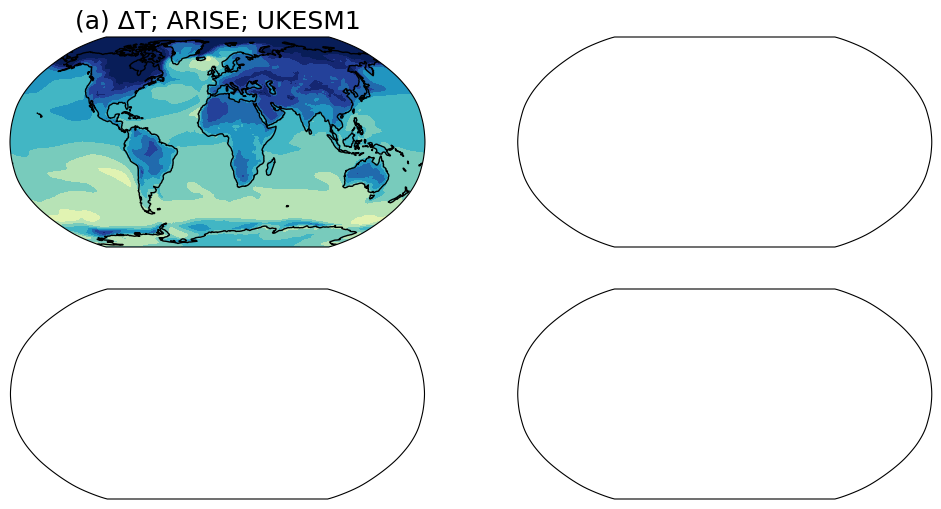

In [17]:

cols = 'YlGnBu_r'
clevs=np.arange(-2.25,0.2,0.25) 

fig, axs = plt.subplots(nrows=2,ncols=2,
                        subplot_kw={'projection': ccrs.Robinson()},
                        figsize=(12,6))


ax = axs.flatten()[0]
model = 'UKESM'
ax.set_title('(a) \u0394T; ARISE; UKESM1')
d = ARISE_cooling_dict[model].sel(time=slice('2050', '2069')).mean('time').tas/(np.mean([x for x in arise_injs[model].values()])/10)
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()

In [18]:

cols = 'YlGnBu_r'
clevs=np.arange(-2.25,0.2,0.25) 

fig, axs = plt.subplots(nrows=2,ncols=2,
                        subplot_kw={'projection': ccrs.Robinson()},
                        figsize=(12,6))

for alt in 
ax = axs.flatten()[0]
model = 'UKESM'
ax.set_title('(a) \u0394T; ARISE; UKESM1')
d = ARISE_cooling_dict[model].tas/(np.mean([x for x in arise_injs[model].values()])/10)
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()

ax = axs.flatten()[1]
ax.set_title('(b) \u0394T; HiLLA-15; UKESM1')
d = HILLS_15_cooling_UK.tas/(12/10)
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()

ax = axs.flatten()[2]
ax.set_title('(c) \u0394T; ARISE; CESM2-WACCM')
d = ARISE_cooling_CE.tas/(np.mean([x for x in arise_injs['CESM'].values()])/10)
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()

ax = axs.flatten()[3]
ax.set_title('(d) \u0394T; HiLLA-15; CESM2-WACCM')
d = HILLS_15_cooling_CE.tas/(12/10)
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()
#sig_mask,lons=add_cyclic_point(models_agree, coord=models_agree['x'])
#cs_hatch = ax.contourf(lons,models_agree['y'],sig_mask,
#                       transform = ccrs.PlateCarree(),
#                       levels=[0, 0.2, 1.2], colors='none',
 #                      hatches=[None,'..', '..'],
#                       extend='neither', zorder=1000)


plt.tight_layout()
# Adjust the location of the subplots on the page to make room for the colorbar
fig.subplots_adjust(bottom=0, top=1, left=0, right=0.85,
                    wspace=0.02, hspace=0.02)

# Add a colorbar axis at the bottom of the graph
cbar_ax = fig.add_axes([0.87, 0.2, 0.05, 0.6])

# Draw the colorbar
cbar=fig.colorbar(cs, cax=cbar_ax,orientation='vertical')
cbar.set_label('\u0394T\nper 10Tg\ninjection\n(°C)', rotation=0, labelpad=40)
cbar.ax.yaxis.label.set_va('center')
#
plt.savefig('Figures/spatial_tas_response_abs_v2.jpg', dpi=300)

SyntaxError: invalid syntax (2357540775.py, line 8)